In [1]:
import kagglehub
from pathlib import Path
from fastcore.all import *
from fastai.vision.all import *
from fastai.vision.widgets import *
import shutil

## Download preprocessed dataset

In [2]:
?kagglehub.dataset_download

Signature: kagglehub.dataset_download(handle: str, path: str | None = None, *, force_download: bool | None = False, output_dir: str | None = None) -> str
Docstring:
Download dataset files
Args:
    handle: (string) the dataset handle
    path: (string) Optional path to a file within a dataset
    force_download: (bool) Optional flag to force download a dataset, even if it's cached or already in output_dir.
    output_dir: (string) Optional output directory for direct download, bypassing the default cache.
Returns:
    A string requesting the path to the requested dataset files.
File:      /usr/local/lib/python3.13/dist-packages/kagglehub/datasets.py
Type:      function


In [3]:
resized_dataset_path = kagglehub.dataset_download('aviramsiginur/resized-dataset')
resized_dataset_path

100%|██████████| 101M/101M [00:07<00:00, 14.0MB/s] 

Extracting files...


'/root/.cache/kagglehub/datasets/aviramsiginur/resized-dataset/versions/1'

In [4]:
failed = verify_images(get_image_files(resized_dataset_path))
len(failed)

0

## Create a DataBlock
- For now I'm using the squishing method which I know is not the best for MRI scans because it changes the proportions of the image. I'm experimenting different methods later in this notebook.

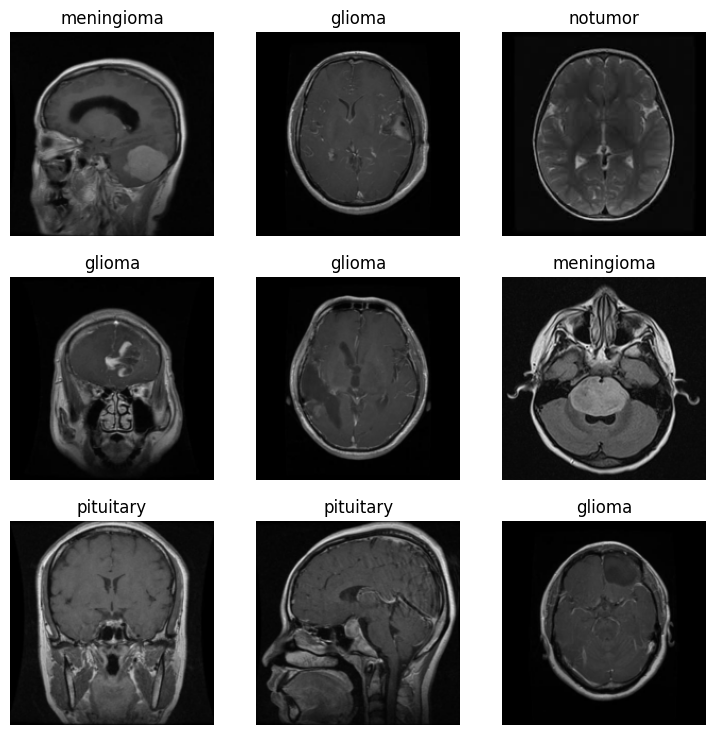

In [5]:
set_seed(42, reproducible=True)
scans = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='Training', valid_name='Testing'),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')])

dls = scans.dataloaders(resized_dataset_path)
dls.show_batch(max_n=9)

> There is too much black background around the brain scans, which is needed to be removed in the preprocessing stage, otherwise the model will use excessive computation for training and the effective resolution will be lower.

In [6]:
type(dls)

fastai.data.core.DataLoaders

In [7]:
def train_model(num_epochs: int) -> Learner:
    """
    Fine tunes resnet18 model with dls object and error rate metric.
    
    Arguments:
        num_epochs(int): the desired number of epochs for the fine tuning.

    Returns:
        learn(Learner): A vision learner trained on the MRI scans and ResNet18 model.
    """
    learn = vision_learner(dls, resnet18, metrics=error_rate)
    learn.fine_tune(num_epochs)
    return learn

## Train a ResNet18 model

In [10]:
learn = train_model(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.717534,0.576054,0.163750,00:26


epoch,train_loss,valid_loss,error_rate,time
0,0.274214,0.496730,0.099375,00:27
1,0.113434,0.409299,0.074375,00:27
2,0.040274,0.402195,0.065625,00:27


> With seed=42: in the 4th epoch, both the validation loss and error rate raised a bit while the train loss decreased, which probably means that the model is overfitted, so I decided to change the number of epochs to 3.

## Predict tumor type in a downloaded MRI scan

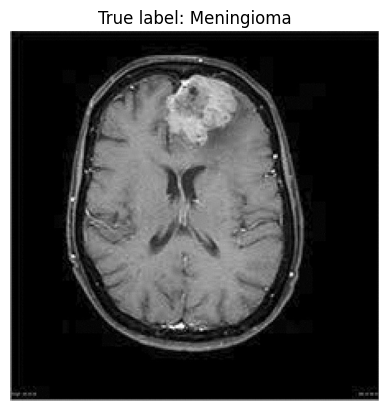

In [11]:
from fastdownload import download_url
import cv2
import matplotlib.pyplot as plt

# Download a meningioma tumor MRI scan from a Nature article
tumor_url = 'https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-023-41576-6/MediaObjects/41598_2023_41576_Fig1_HTML.jpg'
meningioma_example = 'meningioma_tumor.jpg'
download_url(tumor_url, meningioma_example, show_progress=False)

# Show the MRI scan
downloaded_scan = cv2.imread(meningioma_example)
plt.imshow(downloaded_scan)
plt.title('True label: Meningioma')
plt.axis('off')
plt.show()

In [12]:
def predict_tumor_type(img_destination: str) -> None:
    """
    Creates prediction of the image label and prints it as well as
    the confidence of the model it's actually the label of the image.

    Arguments:
        img_destination (str): The image path inside the current working directory.

    Returns:
        None
    """
    prediction, pred_idx, probs = learn.predict(img_destination)
    print(f'Prediction: This is a brain with {prediction}')
    print(f'Probability it\'s a brain with {prediction}: {probs[pred_idx]:.3f}')

In [13]:
predict_tumor_type(meningioma_example)

Prediction: This is a brain with meningioma
Probability it's a brain with meningioma: 1.000


> Good start!

## Experimenting with different item transformations

In [14]:
def update_transformations(data_block: DataBlock, new_item_tfms: List, new_batch_tfms=None, path=resized_dataset_path) -> DataLoaders:
    """
    Creates a new DataBlock with new resizing and/or augmentation item_tfms for the 
    data_block input, shows a batch with 9 images and returns a dataloaders object based on the new datablock.

    Arguments:
        data_block (DataBlock object): An initial DataBlock containing all the variables needed for loading the data into the model.
        new_item_tfms (fast.ai list): New transformation method for the data items.
        new_batch_tfms: New transformation method for the data batches.
        path: The path in which the images exist.
        
    Returns:
        dls (DataLoaders object): A dataloaders object based on the new DataBlock and the folder containing the data.
    """
    set_seed(42, reproducible=True)
    data_block = data_block.new(item_tfms=new_item_tfms, batch_tfms=new_batch_tfms)
    dls = data_block.dataloaders(path)
    dls.show_batch(max_n=9)
    
    return dls

### 1 - Random resized crop

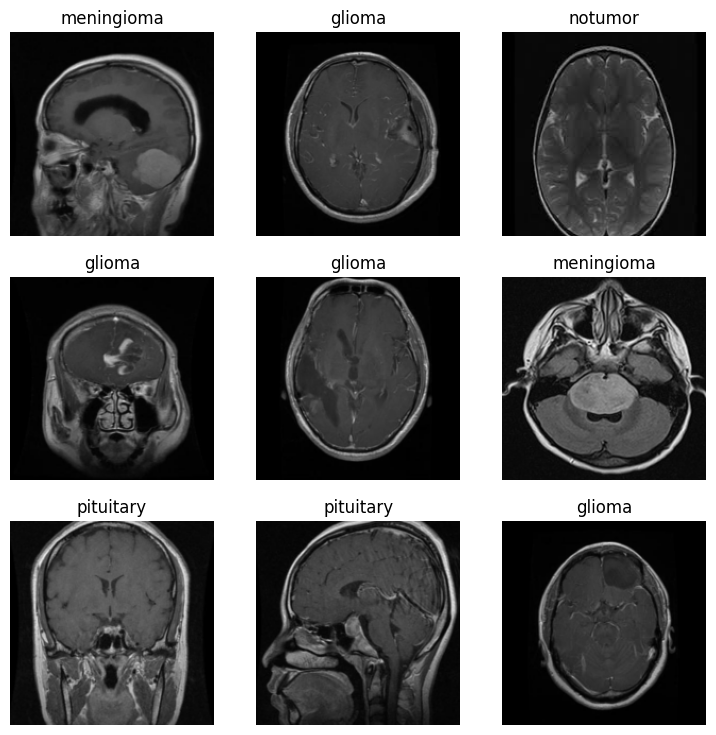

In [15]:
random_resize = RandomResizedCrop(192, min_scale=0.8)
dls = update_transformations(scans, random_resize)

> This method is awful because it crops parts of the brain which may mislead the model or even worse, contain the tumor itself!

### 2 - Padding with zeros

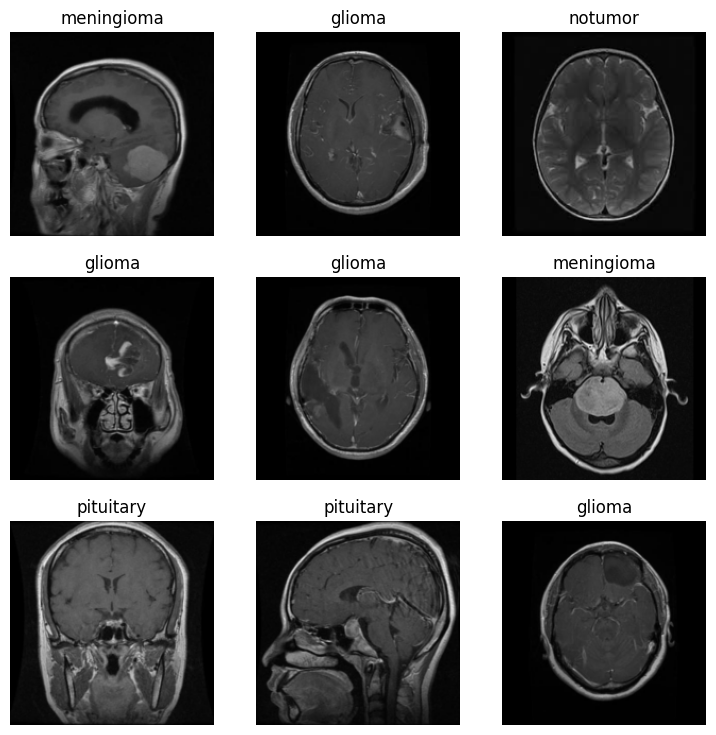

In [16]:
pad_resize = Resize(192, ResizeMethod.Pad, pad_mode='zeros')
dls = update_transformations(scans, pad_resize)

> Now the images are neither squished nor cropped.

## Training with zero padded images

In [17]:
learn = train_model(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.717909,0.605654,0.160625,00:22


epoch,train_loss,valid_loss,error_rate,time
0,0.281417,0.522037,0.110000,00:23
1,0.127169,0.371777,0.066250,00:23
2,0.043195,0.369288,0.062500,00:23


> Compared to the model trained on the squished images, the error_rate decreased by 0.00125, the train_loss decreased by 0.0024 and the valid_loss increased by 0.0145.

> Maybe the new model is a little bit more overfitted but I assume that using padding instead of squishing is more accurate.

In [18]:
predict_tumor_type(meningioma_example)

Prediction: This is a brain with meningioma
Probability it's a brain with meningioma: 1.000


## Plot confusion matrix

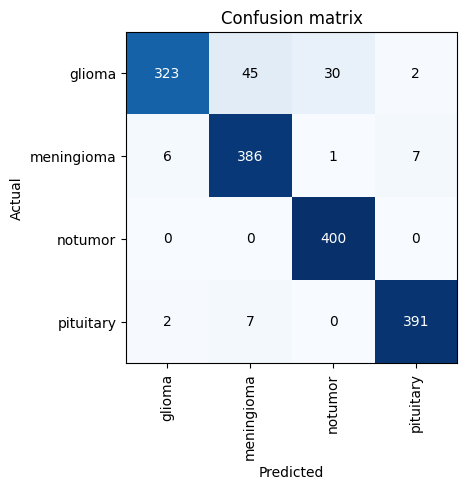

In [19]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

## Data Augmentation

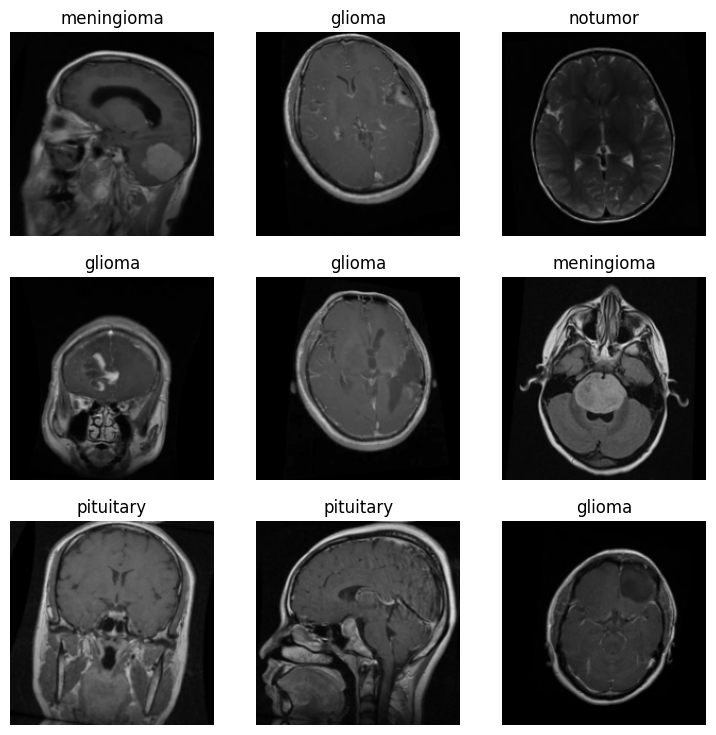

In [20]:
aug_mult1 = aug_transforms(mult=1)
dls = update_transformations(scans, pad_resize, aug_mult1)

In [21]:
# dls.show_batch(max_n=9, unique=True)

In [22]:
learn = train_model(5)

epoch,train_loss,valid_loss,error_rate,time
0,0.795900,0.744606,0.201250,00:23


epoch,train_loss,valid_loss,error_rate,time
0,0.395216,0.489914,0.125625,00:24
1,0.268687,0.473693,0.100000,00:24
2,0.152170,0.416612,0.077500,00:24
3,0.097137,0.353858,0.066250,00:24
4,0.078304,0.345085,0.061875,00:25


> I used 5 epochs because with 6 epochs the model started to be overfitted for the same reasons as the first training of the model.

> The validation loss and error rate decreased while the training loss increased in comparison to what was seen previously, and the number of epochs increased by 2. That's a sign of a more robust model that regularizes better!

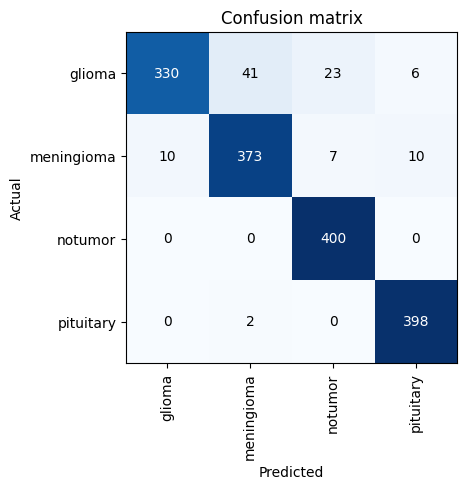

In [23]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

> Conclusion: The model recognizes very well when there's actually no tumor in the brain.

- In 27 cases (1.69%) the model predicts that there's no tumor when there actually is one (FN). In the medical domain it is crucial to reduce the number of FN predictions as much as possible, but good enough for now.
  
- The model has hard time recognizing glioma in comparison to other tumors, which is interesting and should be investigated further. Maybe it's because the images are in 2D and do not represent spatial views (in contrast to DICOM/Nifti), or maybe glioma is hard to recognize and is similar to meningioma/other tumors.

- The images in the dataset are in grayscale, whereas the imagenet dataset, which resnet18 is trained on, contains colourful images.

## View top losses

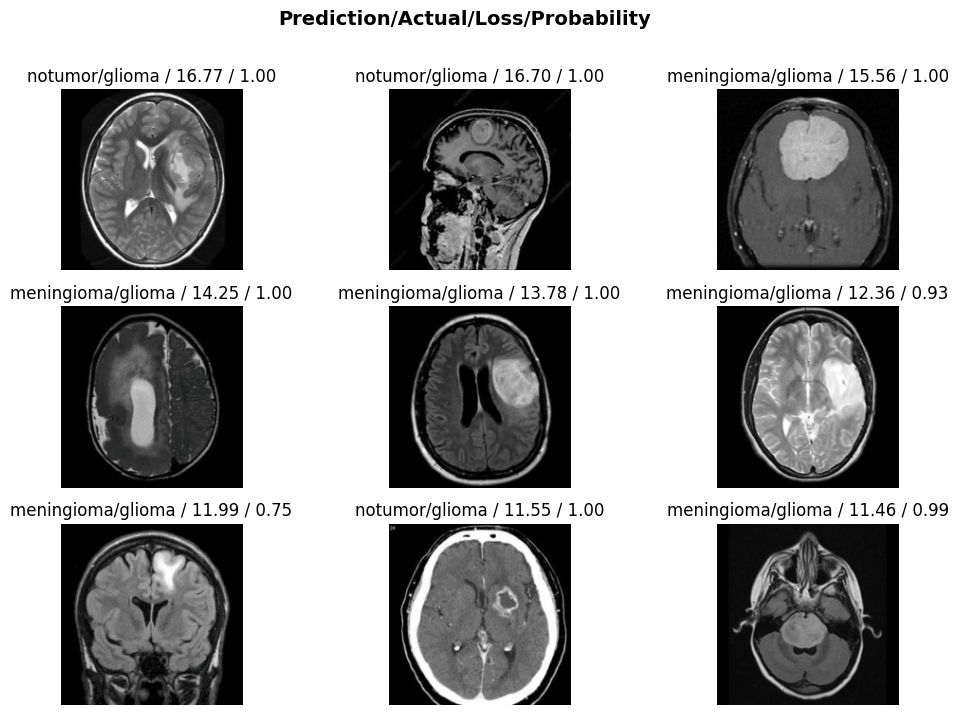

In [24]:
interp.plot_top_losses(9, nrows=3, figsize=(12,8))

> It reveals us that indeed the model is very confused when there's actually a glioma tumor. The model thinks that there's meningioma or no tumor at all when there's glioma. My biggest concern is that it's 100% confident about the wrong prediction in many cases!!

> Maybe there's imbalance in the slices distribution in the dataset, i.e the number of scans of the brain from above is different than the number of scans from the side, although it's more reasonable that the issue is 2D representation rather than 3D.

> There's also a slight chance that the labels of the wrong predictions aren't correct from the beginning.

## Clean dataset

In [25]:
# cleaner = ImageClassifierCleaner(learn)
# cleaner

> I don't think I need to clean the notumor labeled images for now because the model predicted perfectly when there's actually no tumor (the result may change based on the seed, number of commands, parameters, etc).

> It's actually very hard to clean the data by myself because I can't recognize presence of tumors, let alone their kind.

> I can see that in the validation set there are some duplicates! I will delete the ones I see here in the cleaner, but now I'm worried that the whole validation set contains duplicates, maybe even the training one.

> I might also notice that there are significant differences between how the brains and tumors look in the training set vs how they look in the validation set when considering top losses for glioma. But it also might be an advantage because it means that there is a little chance for data leakage.

Note: the files are in read-only mode so I can't modify them in-place. Instead, I am going to save them in a new list and remove the duplicates from it, then I'll save the data as cleaned-dataset. Another option is to first copy all the files from the resized dataset to the current working directory and then use the code to clean the duplicates. 

**I am choosing the second approach.**

In [ ]:
# Remove duplicates selected in the previous cell. Run only when cleaning the model for the first time. Add the printed paths to a list.
# imgs_to_clean = []

: 

: 

: 

In [ ]:
# for idx in cleaner.delete(): 
#     img_to_clean = cleaner.fns[idx]
#     imgs_to_clean.append(img_to_clean)
# imgs_to_clean

: 

: 

: 

In [26]:
# There are the paths of the images I want to clean after running a model with augmented(mult=1) and zero-padded images. Also, the paths are relative!
imgs_to_clean = [Path('Training/pituitary/Tr-pi_1023.jpg'),
 Path('Training/pituitary/Tr-pi_1071.jpg'),
 Path('Training/pituitary/Tr-pi_991.jpg'),
 Path('Testing/glioma/Te-gl_171.jpg'),
 Path('Testing/glioma/Te-gl_129.jpg'),
 Path('Testing/glioma/Te-gl_204.jpg'),
 Path('Testing/notumor/Te-no_386.jpg')]

In [30]:
dir_cleaned = Path.cwd() / 'cleaned-dataset'
shutil.copytree(Path(resized_dataset_path) / 'resized-dataset', dir_cleaned, dirs_exist_ok = True)

Path('/content/cleaned-dataset')

In [31]:
for img in imgs_to_clean:
    img_in_dest = dir_cleaned / img
    if img_in_dest.exists():
        img_in_dest.unlink()

## Train the model with cleaned dataset

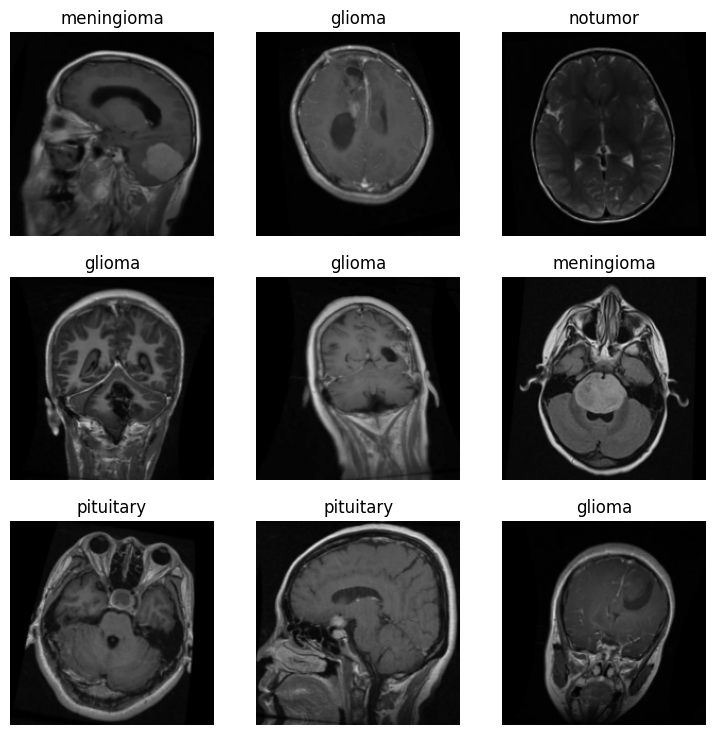

In [32]:
dls = update_transformations(scans, pad_resize, aug_mult1, dir_cleaned)

In [33]:
learn = train_model(7)

epoch,train_loss,valid_loss,error_rate,time
0,0.791866,0.705146,0.192356,00:24


epoch,train_loss,valid_loss,error_rate,time
0,0.380064,0.484481,0.115915,00:25
1,0.269538,0.466848,0.090226,00:25
2,0.185422,0.466399,0.089599,00:25
3,0.115851,0.360067,0.074561,00:24
4,0.078712,0.386827,0.065163,00:24
5,0.052702,0.340960,0.058271,00:25
6,0.047364,0.339182,0.052005,00:25


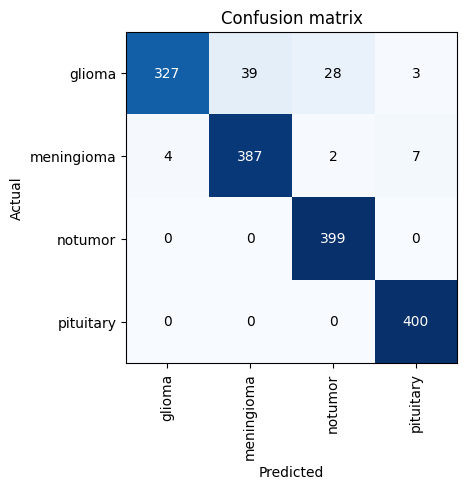

In [34]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

> The results are definitely better compared to the previous model and the number of epochs raised by 2. Even with small cleaning the model generalizes better!

## Deployment

In [35]:
learn.export('model.pkl')